Importamos nuestras librerías y establecemos la conexión a postgreSQL con SQLalchemy, las consultas serán directamente importadas desde texto guardado en la carpeta SQL en la raíz del proyecto.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import text
from src.db import get_engine
from src.paths import REPORTS_DIR, SQL_DIR

engine = get_engine()

# 1. Análisis temporal

Partiremos con lo más simple: las columnas `hour_of_day` y `simulation_day` representan los días y horas en que se efectúan las transacciones, utilizando estas columnas veremos el porcentaje de operaciones fraudulentas del total de operaciones efectuadas durante el marco temporal elegido.

## 1.1. Análisis por día

La siguiente consulta agrupa las 2 operaciones de `type` que concentran todo el fraude por: la cantidad total de transacciones, la cantidad fraudulenta de transacciones, la cantidad defraudada, el porcentaje de operaciones fraudulentas del total de operaciones efectuadas y las indexa por el día de la simulación. Con la tabla resultante podremos responder el cómo varía la tasa de fraude a través de los días para ambos tipos de transacción.

In [2]:
query_path = (
    SQL_DIR / "fraud_by_day.sql"
)
query = text(
    query_path.read_text()
)
fraud_by_day = pd.read_sql_query(
    sql=query,
    con=engine
)
fraud_by_day

,simulation_day,type,transaction_count,fraud_count,fraudulent_amount,fraud_rate_pct
0,1,CASH_OUT,204397,141,1.050523e+08,0.0690
1,1,TRANSFER,46686,130,1.061115e+08,0.2785
2,2,CASH_OUT,164605,156,1.895422e+08,0.0948
3,2,TRANSFER,38269,153,1.896975e+08,0.3998
4,3,CASH_OUT,240,155,1.972544e+08,64.5833
...,...,...,...,...,...,...
57,29,TRANSFER,5348,130,2.509734e+08,2.4308
58,30,CASH_OUT,4047,134,2.469157e+08,3.3111
59,30,TRANSFER,1014,134,2.500868e+08,13.2150
60,31,CASH_OUT,136,136,2.125477e+08,100.0000


Vamos a graficar esto, será más fácil visualizar y sacar conclusiones. Primero veremos la cantidad de transacciones totales diarias contra la cantidad de transacciones fraudulentas, luego graficaremos la tasa de fraude, así responderemos cómo varía esta tasa diariamente.

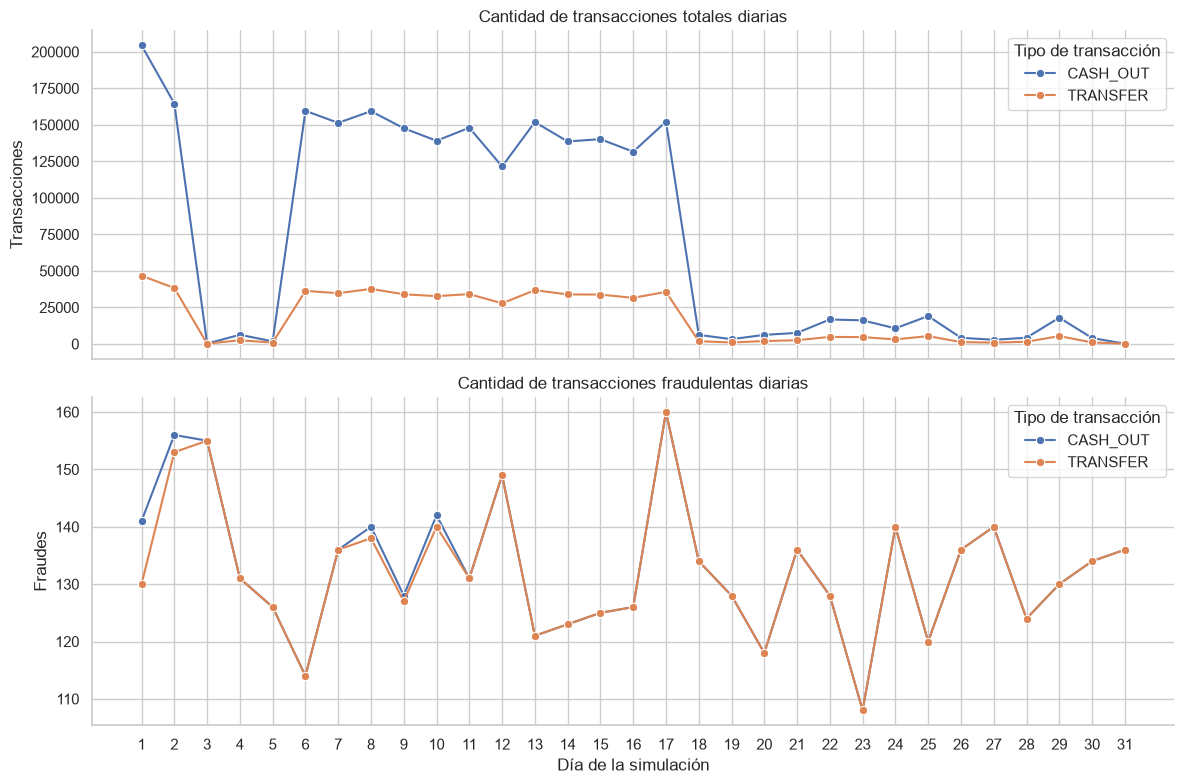

In [3]:
sns.set_theme(
    style="whitegrid", context="notebook"
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


sns.lineplot(
    data=fraud_by_day, 
    x="simulation_day", 
    y="transaction_count", 
    hue="type", 
    marker="o", 
    ax=ax1
)
ax1.set_title(
    "Cantidad de transacciones totales diarias"
)
ax1.set_ylabel(
    "Transacciones"
)
ax1.legend(
    title="Tipo de transacción"
)


sns.lineplot(
    data=fraud_by_day, 
    x="simulation_day", 
    y="fraud_count", 
    hue="type", 
    marker="o", 
    ax=ax2
)

ax2.set_title(
    "Cantidad de transacciones fraudulentas diarias"
)
ax2.set_xlabel(
    "Día de la simulación"
)
ax2.set_ylabel(
    "Fraudes"
)
ax2.legend(
    title="Tipo de transacción"
)

plt.xticks(
    sorted(fraud_by_day["simulation_day"].unique())
)
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "daily_transactions.png", dpi=150)
plt.show()

Primero podemos ver cómo la cantidad de transacciones totales varía mucho por día, la meseta del día 6 al 17 eclipsa prácticamente todo el resto del mes, probablemente por la estacionalidad de pagos de salarios, lo que podría explicar también el pico del primer y segundo día, mas no tenemos información que nos pueda confirmar esto, así que sólo queda como hipótesis.

En contraste, las transacciones fraudulentas son relativamente estables: la cantidad de fraudes no baja de 100 durante todo el mes, diciéndonos que el fraude no descansa. Además la gran mayoría de operaciones fraudulentas tienen una correspondencia 1 a 1 entre tipos de transacción, o sea, la relación entre ambos puede estar unida a un patrón de fraude que las implica, vamos a nalizar esta hipótesis en la siguiente sección.

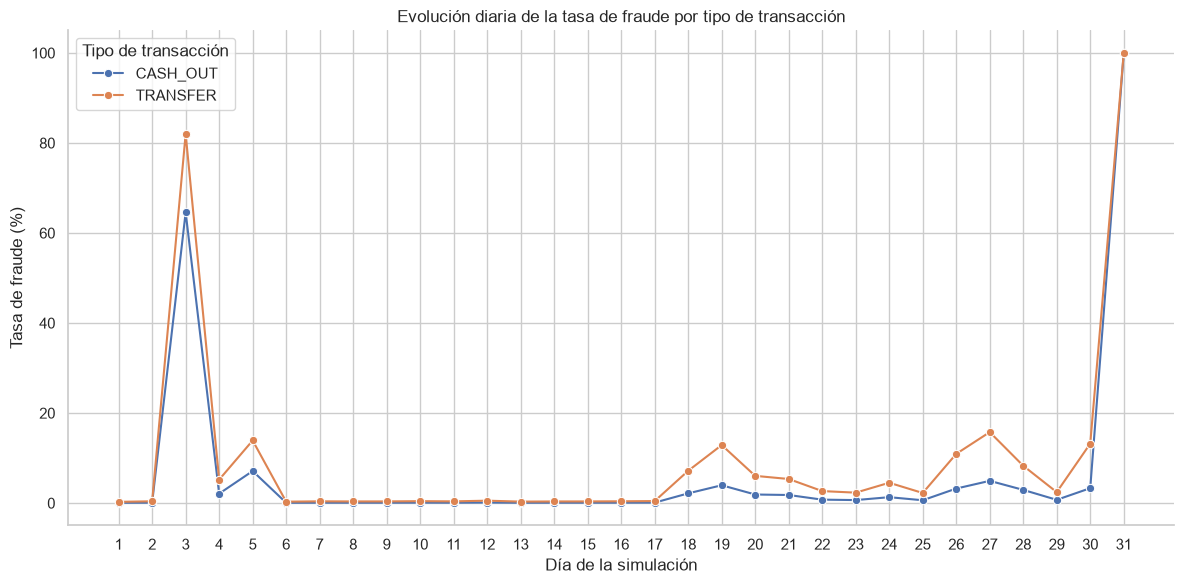

In [4]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=fraud_by_day,
    x="simulation_day",
    y="fraud_rate_pct",
    hue="type",
    marker="o",
    estimator=None,
    errorbar=None,
    ax=ax,
)

ax.set(
    title="Evolución diaria de la tasa de fraude por tipo de transacción",
    xlabel="Día de la simulación",
    ylabel="Tasa de fraude (%)",
)

ax.legend(
    title="Tipo de transacción",
)

ax.set_xticks(
    sorted(fraud_by_day["simulation_day"].unique())
)

sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "daily_rate.png", dpi=150)
plt.show()

Conociendo los datos anteriores se hace evidente que el porcentaje de fraude por día es relativo a la cantidad total de transacciones: los días menos activos en `transaction_count` son los que tienen valores más altos en `fraud_rate_pct` y viceversa, la meseta de actividad del 6 al 17 entierran la tasa de fraude.

## 1.2. Análisis por hora

En esta consulta haremos prácticamente lo mismo que en la anterior, pero indexando por `hour_of_day` en lugar de `simulation_day`, por lo que tendremos 48 filas en lugar de 62 como en la anterior. Aquí responderemos si existen horas en específico que tengan mayor posibilidad de ser fraudulentas.

In [5]:
query_path = (
    SQL_DIR / "fraud_hour.sql"
)
query = text(
    query_path.read_text()
)
fraud_hour = pd.read_sql_query(
    sql=query,
    con=engine
)

fraud_hour.head()

,hour_of_day,type,transaction_count,fraud_count,fraudulent_amount,fraud_rate_pct
0,0,CASH_OUT,3898,180,1.836172e+08,4.6178
1,0,TRANSFER,2107,178,1.830684e+08,8.4480
2,1,CASH_OUT,1256,186,3.483015e+08,14.8089
3,1,TRANSFER,666,186,3.518778e+08,27.9279
4,2,CASH_OUT,432,163,3.118339e+08,37.7315


Grafiquemos otra vez, seguro que nos da información interesante.

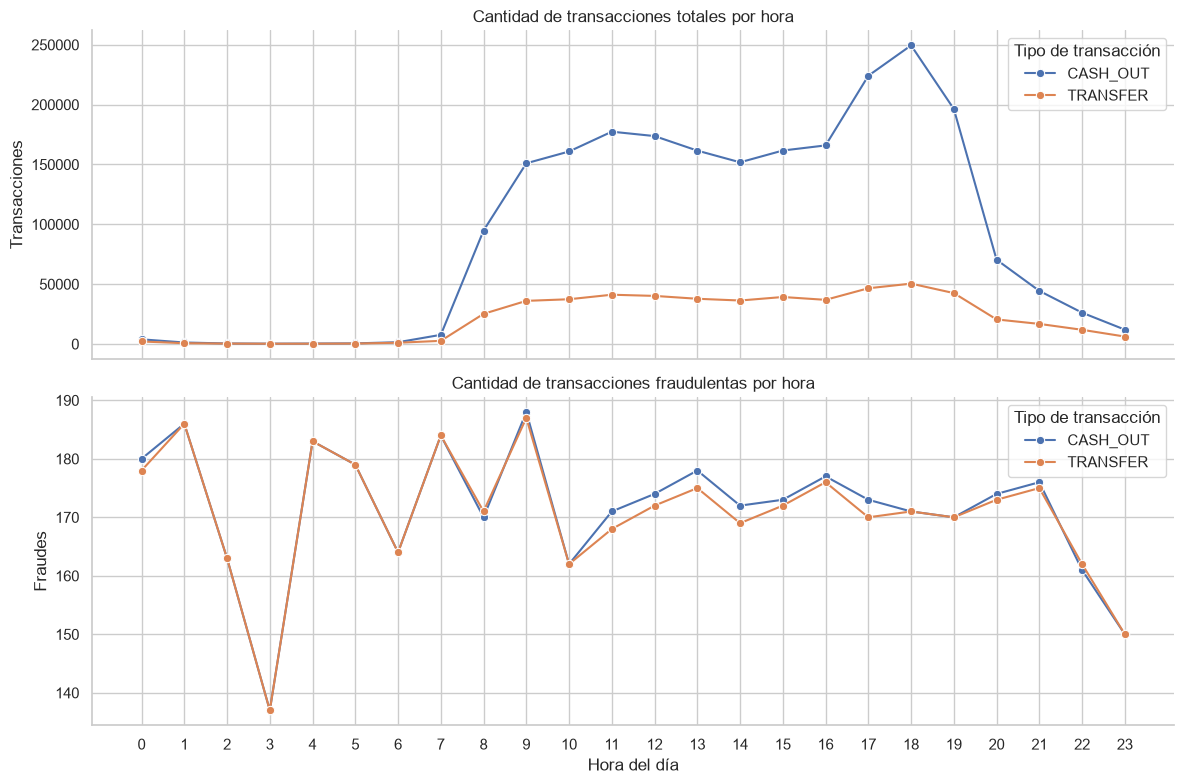

In [6]:
sns.set_theme(
    style="whitegrid", context="notebook"
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


sns.lineplot(
    data=fraud_hour, 
    x="hour_of_day", 
    y="transaction_count", 
    hue="type", 
    marker="o", 
    ax=ax1
)
ax1.set_title(
    "Cantidad de transacciones totales por hora"
)
ax1.set_ylabel(
    "Transacciones"
)
ax1.legend(
    title="Tipo de transacción"
)


sns.lineplot(
    data=fraud_hour, 
    x="hour_of_day", 
    y="fraud_count", 
    hue="type", 
    marker="o",
    ax=ax2
)
ax2.set_title(
    "Cantidad de transacciones fraudulentas por hora"
)
ax2.set_xlabel(
    "Hora del día"
)
ax2.set_ylabel(
    "Fraudes"
)
ax2.legend(
    title="Tipo de transacción"
)

plt.xticks(
    sorted(fraud_hour["hour_of_day"].unique())
)
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "hourly_transactions.png", dpi=150)
plt.show()

Ok, la mayoría de transacciones se hacen durante el día, de 8 am a 20 pm. De nuevo el fraude no varía tanto, sólo hay dos horas donde se baja de los 160, todo el resto esté entre esa cifra y 190.

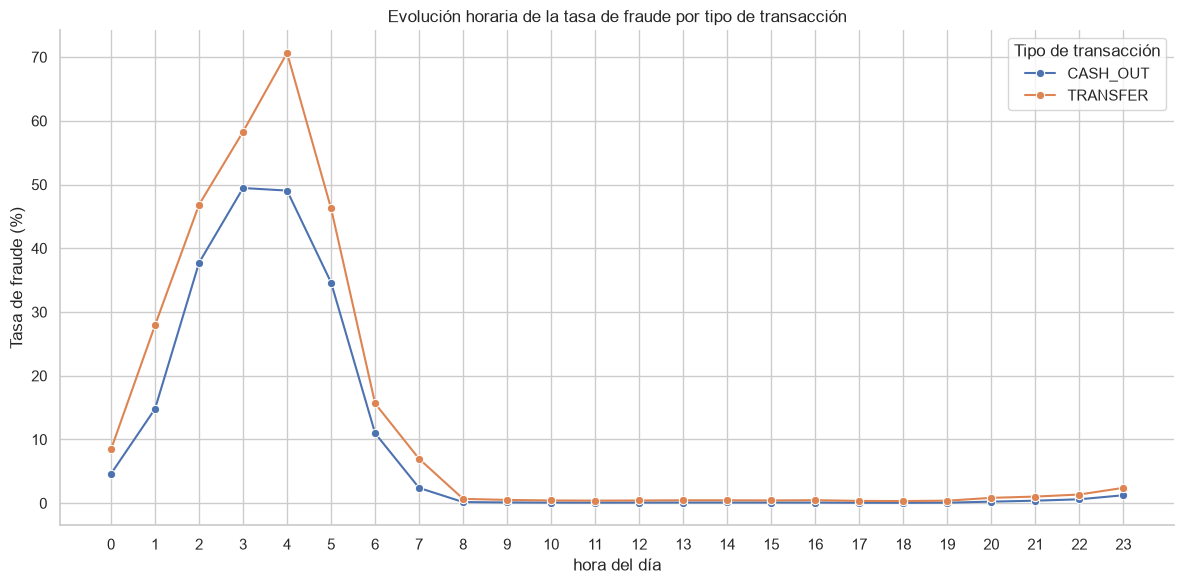

In [7]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=fraud_hour,
    x="hour_of_day",
    y="fraud_rate_pct",
    hue="type",
    marker="o",
    estimator=None,
    errorbar=None,
    ax=ax,
)

ax.set(
    title="Evolución horaria de la tasa de fraude por tipo de transacción",
    xlabel="hora del día",
    ylabel="Tasa de fraude (%)",
)

ax.legend(
    title="Tipo de transacción",
)

ax.set_xticks(
    sorted(fraud_hour["hour_of_day"].unique())
)

sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "hourly_rate.png", dpi=150)
plt.show()

La conclusión es similar: el fraude tampoco reconoce horas y el alto porcentaje de fraude a ciertas horas se corresponde a la baja cantidad de transacciones en general a las mismas horas.

# 2. Análisis de patrón de fraude

A través de estas tablas y gráficos pudimos observar la igualdad en la cantidad de operaciones fraudulentas y formulamos una hipótesis: que existe un patrón de fraude que implica las dos operaciones como una unidad, ahora pondremos a prueba esto. Además casi no usamos la columna `fraudulent_amount` en las exploraciones anteriores, ahora nos serán útiles.

## 2.1 Agregaciones de montos

Primero pivotaremos la tabla `fraud_hour` dejando las categorías de `type` como columnas y con los valores de `fraudulent_amount`.

In [8]:
type_pivot = fraud_hour.pivot(
    index="hour_of_day", 
    columns="type", 
    values="fraudulent_amount"
)

type_pivot["diff_pct"] = (
    (
        type_pivot["CASH_OUT"] 
        - type_pivot["TRANSFER"]
    ).abs() 
    / type_pivot["TRANSFER"]
) * 100

type_pivot.describe()

type,CASH_OUT,TRANSFER,diff_pct
count,2.400000e+01,2.400000e+01,24.000000
mean,2.495501e+08,2.528005e+08,1.224954
std,5.689458e+07,5.984211e+07,1.795744
min,1.651558e+08,1.651558e+08,0.000000
25%,2.045579e+08,2.052522e+08,0.236572
50%,2.416153e+08,2.411785e+08,0.454998
75%,3.083279e+08,3.125223e+08,1.548988
max,3.483015e+08,3.535374e+08,7.403074


La descripción de la tabla `type_pivot` nos indica que la diferencia porcentual promedio es de apenas 1.22%, otra evidencia que podría soportar nuestra hipótesis, pero no podemos adelantarnos a sacar conclusiones sin una prueba empírica, por lo que una consulta es necesaria.

## 2.2 comprobación de patrón de fraude

Un `JOIN` en las cuentas de destino de operaciones `TRANSFER` fraudulentas con las cuentas de origen de operaciones `CASH_OUT` y además uniendo las horas exactas de `step` debería ser suficientemente robusto para encontrar la prueba que necesitamos, deberíamos encontrar filas con nombres de cuentas, montos transferidos y horas repetidas.

In [9]:
query_path = (
    SQL_DIR / "fraud_succession.sql"
)
query = text(
    query_path.read_text()
)
fraud_succession = pd.read_sql_query(
    sql=query,
    con=engine
)

fraud_succession

,transfer_name,cashout_name,transfer_amount,cashout_amount,cashout_step,transfer_step


Está vacío... es un poco decepcionante; pero nos dice algo valioso: que no es posible probar el patrón de fraude del dataset buscando una conexión en los nombres de las cuentas involucradas. Sabiendo lo anterior se hace imposible encontrar una prueba empírica que demuestre el patrón; no significa que no podamos acercanos a una respuesta. Buscando una cardinalidad 1 a 1 entre un `TRANSFER` y un `CASH_OUT` con el mismo `amount` y en el mismo `step` podría fortalecer nuestra hipótesis del modus operandi de dos pasos, en caso de que sea la cardinalidad más común. Primero vamos a ver que tan comunes son las operaciones con cardinalidad varios a varios.

In [10]:
query_path = (
    SQL_DIR / "amount_freq.sql"
)
query = text(
    query_path.read_text()
)
amount_freq = pd.read_sql_query(
    sql=query,
    con=engine
)

amount_freq

,amount,step,transfers,cash_outs,total_freq
0,10000000.0,387,6,6,12
1,10000000.0,646,6,5,11
2,10000000.0,425,5,4,9
3,10000000.0,730,5,4,9
4,10000000.0,741,4,4,8
5,10000000.0,617,4,4,8
6,10000000.0,440,4,4,8
7,10000000.0,554,3,3,6
8,10000000.0,671,3,3,6
9,10000000.0,710,3,3,6


Ok, tenemos varias llaves de cardinalidad varios a varios, varias de ellas simétricas y otras no, veamos la distribución de estas claves.

In [11]:
query_path = (
    SQL_DIR / "type_cardinality.sql"
)
query = text(
    query_path.read_text()
)
type_cardinality = pd.read_sql_query(
    sql=query,
    con=engine
)

type_cardinality

,transfers,cash_outs,quantity
0,1,1,3997
1,0,1,35
2,1,0,19
3,2,2,10
4,3,3,9
5,0,2,3
6,4,4,3
7,5,4,2
8,6,6,1
9,6,5,1


ok, la cantidad de claves con cardinalidad 1 a 1 es la más elevada, lo que apoya nuestra hipótesis del fraude. Además hay varias con cardinalidad muchos a muchos simétricas, sabemos que todas estas, las simétricas, tranzan la misma cantidad: 10000000, esto es claramente un indicio de una estrategia de smurfing o estructuración, cuando una cantidad muy grande de dinero se subdivide en cantidades más pequeñas para evadir alertas, tampoco hay transacciones fraudulentas con montos mayores, mas sí hay no-fraudulentas con montos mucho mayores, vale la pena comprobarlo: 

In [12]:
query_path = (
    SQL_DIR / "max_amounts.sql"
)
query = text(
    query_path.read_text()
)
max_amounts = pd.read_sql_query(
    sql=query,
    con=engine
)

max_amounts

,max_fraud_amount,max_non_fraud_amount
0,10000000.0,92445516.64


ya, el mayor monto no fraudulento es más de 9 veces más grande que el mayor fraudulento. Haremos otra demostración, mostrando las cantidades de las cuentas que hacen transacciones `TRANSFER` fraudulentas.

In [13]:
query_path = (
    SQL_DIR / "fraud_strategy.sql"
)
query = text(
    query_path.read_text()
)
fraud_strategy = pd.read_sql_query(
    sql=query,
    con=engine
)

fraud_strategy

,amount,oldbalance_orig
0,10000000.0,10175597.64
1,10000000.0,10185510.21
2,10000000.0,10353874.22
3,10000000.0,10390763.24
4,10000000.0,10399045.08
...,...,...
140,10000000.0,47316255.05
141,10000000.0,49585040.37
142,10000000.0,50399045.08
143,10000000.0,57316255.05


Ya, toda cuenta que transfiere 10000000.0 tiene siempre más que tal monto en su cuenta, por lo que podemos descartar que es un techo impuesto por el sistema.

Para concluir esta sección: mientras no podemos demostrar empíricamente el patrón de fraude en 2 pasos vinculando los nombres de cuentas involucradas en éste. Sí hay evidencia para sostener la hipótesis: la cardinalidad 1 a 1 dominante en transacciones `TRANSFER` y `CASH_OUT`en el mismo step y con el mismo monto, la casi simetría en la cantidad de cada operación fraudulenta, la recurrencia de operaciones varios a varios simétricas con montos iguales junto al techo transaccional que separa el máximo monto fraudulento y el máximo no-fraudulento nos apunta fuertemente a un patrón de 2 pasos que utiliza estrategias de smurfing o estructuración para pasar bajo los radares del sistema de detección de fraude del sistema. Estos descubrumientos podrán ayudarnos a proponer mejoras a los sistemas de detección de este patrón de fraude, mas primero debemos encontrar más reglas para encontrar señales de fraude.

# 3. Señales y detección de fraude

## 3.1. Perfilación de sistema de detección

Veamos la distribución de `is_flagged_fraud` y `is_fraud`

In [14]:
query_path = (
    SQL_DIR / "fraud_count.sql"
)
query = text(
    query_path.read_text()
)
fraud_count = pd.read_sql_query(
    sql=query,
    con=engine
)

fraud_count

,is_flagged_fraud,is_fraud,count
0,False,False,6354407
1,False,True,8197
2,True,True,16


Ok, no hay falsos positivos pero el sistema es extremadamente deficiente en detectar fraude, marcando cerca del 0,2% del fraude total. Veamos qué elementos tienen los marcados como fraude y quizá podmos extrapolar algo.

In [15]:
query_path = (
    SQL_DIR / "flaggeds.sql"
)
query = text(
    query_path.read_text()
)
flaggeds = pd.read_sql_query(
    sql=query,
    con=engine
)

flaggeds

,step,type,amount,hour_of_day,simulation_day
0,586,TRANSFER,353874.22,9,25
1,646,TRANSFER,399045.08,21,27
2,279,TRANSFER,536624.41,14,12
3,250,TRANSFER,1343002.08,9,11
4,617,TRANSFER,2542664.27,16,26
5,702,TRANSFER,3171085.59,5,30
6,671,TRANSFER,3441041.46,22,28
7,554,TRANSFER,3576297.10,1,24
8,387,TRANSFER,4892193.09,2,17
9,212,TRANSFER,4953893.08,19,9


In [16]:
flaggeds.describe()

,step,amount,hour_of_day,simulation_day
count,16.000000,1.600000e+01,16.000000,16.000000
mean,537.562500,4.861598e+06,13.062500,22.812500
std,181.895196,3.572499e+06,6.903803,7.564996
min,212.000000,3.538742e+05,1.000000,9.000000
25%,415.500000,2.242749e+06,9.000000,17.750000
50%,601.500000,4.234245e+06,15.000000,25.500000
75%,678.750000,7.883451e+06,19.250000,28.500000
max,741.000000,1.000000e+07,22.000000,31.000000


In [17]:
query_path = (
    SQL_DIR / "frauds.sql"
)
query = text(
    query_path.read_text()
)
frauds = pd.read_sql_query(
    sql=query,
    con=engine
)

frauds.describe()

,step,amount,hour_of_day,simulation_day
count,8213.000000,8.213000e+03,8213.000000,8213.000000
mean,368.413856,1.467967e+06,11.423110,15.832948
std,216.388690,2.404253e+06,6.876553,9.017848
min,1.000000,0.000000e+00,0.000000,1.000000
25%,181.000000,1.270913e+05,5.000000,8.000000
50%,367.000000,4.414234e+05,11.000000,16.000000
75%,558.000000,1.517771e+06,17.000000,24.000000
max,743.000000,1.000000e+07,23.000000,31.000000


Ok, los sesgos del sistema son claros: sólo es capaz de ver los `TRANSFER`, su regla de montos es demasiado estricta y sólo atrapa montos relativamente altos, no atrapa montos menores a 350 mil, además, no parece observar el `step` de las transacciones. Tratemos implementar un mejor sistema y veamos si somos capaces de mejorar el antiguo.

## 3.2. Nuevo sistema de detección

Nuestra regla opera directamente sobre los descubrimientos anteriores: agrupamos todas las transacciones `TRANSFER` y `CASH_OUT` que comparten el mismo `amount` y `step` y las contamos en un CTE, cruzamos éste con el dataset completo con un inner join en `step`y `amount` buscando parejas que existen exactamente una vez.

In [18]:
query_path = (
    SQL_DIR / "new_detection_rule.sql"
)
query = text(
    query_path.read_text()
)
new_detection_rule = pd.read_sql_query(
    sql=query,
    con=engine
)

new_detection_rule

,is_fraud,is_flagged_fraud,new_detection_rule
0,True,False,True
1,True,False,True
2,True,False,True
3,True,False,True
4,True,False,True
...,...,...,...
8095,True,False,True
8096,True,False,True
8097,True,False,True
8098,True,False,True


Ok, nuestra regla parece capturar muchos más fraudes, veamos qué tan eficiente es en realidad comparándola en una matriz de confusión con la regla original.

In [19]:
query_path = (
    SQL_DIR / "confusion_matrix.sql"
)
query = text(
    query_path.read_text()
)
confusion_matrix = pd.read_sql_query(
    sql=query,
    con=engine
)

confusion_matrix

,rule_name,generated_alerts,true_positives,false_positives,false_negatives,true_negatives,precision_pct,recall_pct,specificity_pct,f1_score_pct
0,original_rule,16,16,0,8197,6354407,100.0000,0.1948,100.0000,0.3889
1,new_rule,8100,7980,120,233,6354287,98.5185,97.1630,99.9981,97.8361


De los 8100 marcados por nuestro nuevo sistema 120 son falsos positivos, tenemos un 98.5% de tasa de precisión y un valor-F de cerca del 98%. Podría ser afinado más, pero está un poco fuera de nuestros objetivos con este cuaderno, aún así consideramos esta propuesta un éxito total.

Ahora veamos qué monto defraudado es capaz de recapturar esta nueva regla vs el original.

In [20]:
query_path = (
    SQL_DIR / "fraud_amount_recapture.sql"
)
query = text(
    query_path.read_text()
)
fraud_amount_recapture = pd.read_sql_query(
    sql=query,
    con=engine
)

fraud_amount_recapture

,total_fraud_amount,old_rule_recaptured_amount,new_rule_recaptured_amount,old_rule_recapture_pct,new_rule_recapture_pct
0,1.205642e+10,77785563.69,1.038640e+10,0.65,86.15


Ya, la diferencia es abismal, nuestra regla es capaz de recuperar mucho más dinero que la original pero con el precio de algunos falsos positivos.

El sistema original recupera apenas el 0.65% del monto total defraudado y cerca de 78 millones de 12.056 mil millones; nuestra regla eleva esa cifra al 86.15% y a 10.4 mil millones, un salto de 85 puntos porcentuales, al costo de 120 falsos positivos sobre 8100 alertas generadas.

Como mencionamos antes, la regla se puede afinar más: se podrían perfilar los falsos positivos y los falsos negativos para encontrar reglas nuevas, mas eso sería entrar en el terreno del feature engineering, que no es lo que se trabaja en este cuaderno, sino que se limita a hacer análisis de los datos dados.

# 4. Limitaciones

Mientras PaySim es útil para simular patrones de fraude y se puede sacar mucha información interesante por su magnitud de contenido, tiene limitaciones dada su construcción de la que emanan limitaciones en las posibilidades de análisis: el hecho de que no exista información de calendario dentro de la simulación nos priva de la dimensión analítica de la estacionalidad y ciclos semanales y mensuales. El sesgo hacia sólo 2 tipos de operaciones que concentran todo el fraude (`TRANSFER` y `CASH_OUT`) significa también una limitación de las posibilidades de análisis a otros patrones o técnicas de fraude. También la anonimización de nombres de cuentas de origen hace imposible hacer pruebas que demuestren empíricamente el patrón de 2 pasos y la estrategia de smurfing o estructuración. 

In [21]:
query_path = (
    SQL_DIR / "name_orig_anonymization.sql"
)
query = text(
    query_path.read_text()
)
name_orig_anonymization = pd.read_sql_query(
    sql=query,
    con=engine
)

name_orig_anonymization

,name_orig,times
0,C1000000639,1
1,C1000001337,1
2,C1000001725,1
3,C1000002591,1
4,C1000003372,1
...,...,...
6353302,C999996999,1
6353303,C999998175,1
6353304,C999999254,1
6353305,C999999614,1


Más de 6 millones de fila y la gran mayoría de cuentas aparecen sólo 1 vez. 

Mientras la regla creada para mejorar el sistema anterior tiene optimizaciones sustanciales, no es perfecta y la exploración y refinación de ésta tampoco fue ahondada en este proyecto.

A parte de la incosistencia de los nombres de cuentas existen también errores de balance, donde las transacciones no reflejan los montos que deberían en las cuentas de destino.

# 5. Conclusiones

En el principio, los análisis temporales nos mostraron que la cantidad de fraudes se mantiene relativamente estable ya sea a través de las horas o de los días y que son las transacciones en general las que presentan variaciones en las distintas escalas temporales de la simulación.

Luego, el estudio del patrón de fraude nos llevó a encontrar una correspondencia muy fuerte entre dos tipos de operaciones en todas las transacciones fraudulentas (`TRANSFER` y `CASH_OUT`): encontramos que ambas operaciones compartían montos casi iguales cada una a través de un pivot de tabla y tratamos de encontrar una prueba empírica tratando de unir el ID de las cuentas a las que se hacían transferencias con el ID de las cuentas recibidoras y que retiraban cantidades iguales de dinero con un inner join, sin embargo no fue posible probar esta conexión a causa de la anonimización de los identificadores de cuentas de origen, este hecho nos obligó a encontrar una prueba indirecta a través de la cardinalidad de las operaciones, donde dominan las 1 a 1 con exactamente el mismo `amount` y `step`, siempre de un `TRANSFER` a un `CASH_OUT`, esto debe verse como una evidencia estadística, no como una demostración.

También, gracias a la exploración de cardinalidad encontramos una concentración de transacciones con montos repetidos y en el mismo `step` por 10 millones, todas las cuentas que transfirieron tenían montos pre-transacción mayores a 10 millones, tampoco hay transacciones fraudulentas que superen ese monto; hay muchos ejemplos de transferencias no-fraudulentas con montos mucho mayores, todos estos fenómenos acumulados nos indican una estrategia de smurfing o estructuración, mas no podemos saber con certeza.

Mientras la regla original tiene una precisión del 100% encontramos que también tiene un recall de 0,19%, nuestra regla propuesta alcanza una precisión del 98,52% y un recall del 97,16%.

Concluyendo: una regla construida a partir de patrones observables dentro del mismo dataset puede mejorar considerablemente el recall respecto a la regla original, la limitación es esa misma: que sólo se utilizan las reglas de la misma simulación, por lo que su aplicabilidad en entornos reales es limitada.